# 04 — Primary analysis, secondaries, guardrails, segments

The end-to-end analysis of the experiment whose data was generated in `01_simulate_funnel.ipynb` and pre-flight checked in `03_preflight_srm_aa.ipynb`.

Order of operations:
1. Primary metric: completion rate via two-proportion z-test.
2. Secondaries: AOV and items per order via Welch's t-test (continuous, unequal variance).
3. Guardrails: per-order refund rate, cart abandonment, page-load time (one-sided, adverse direction).
4. Segments: completion rate sliced by is_returning, is_mobile, high_aov. Bonferroni and Benjamini-Hochberg corrections both shown.
5. The explicit "why cherry-picking is wrong" callout.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

from src import config
from src.io_utils import load_events, load_manifest
from src.stats import two_proportion_ztest, welch_ttest
from src.guardrails import all_guardrails
from src.segments import run_segments, adjust_pvalues
from src.viz import ci_forest_plot

FIG_DIR = ROOT / 'reports' / 'figures'

events = load_events(config.EXPERIMENT_EVENTS_PARQUET)
truth = load_manifest(config.GROUND_TRUTH_JSON)
control = events[events.arm == 'control']
treatment = events[events.arm == 'treatment']
print(f'n control:   {len(control):,}')
print(f'n treatment: {len(treatment):,}')
print(f'true lift baked in: {truth["true_lift_pp"]:.2f} pp')

n control:   24,814
n treatment: 25,186
true lift baked in: 2.50 pp


## 1. Primary metric: completion rate

In [2]:
primary = two_proportion_ztest(
    successes_c=int(control.completion.sum()),
    n_c=len(control),
    successes_t=int(treatment.completion.sum()),
    n_t=len(treatment),
)

rate_c = control.completion.mean()
rate_t = treatment.completion.mean()
print(f'control completion rate:    {rate_c:.4f}')
print(f'treatment completion rate:  {rate_t:.4f}')
print(f'observed lift:              {primary.point_estimate*100:+.3f} pp')
print(f'95% CI:                     [{primary.ci_low*100:+.3f}, {primary.ci_high*100:+.3f}] pp')
print(f'z statistic:                {primary.statistic:.3f}')
print(f'p-value:                    {primary.pvalue:.6f}')
print(f'significant at alpha=0.05:  {primary.significant()}')
print()
true_lift = truth['true_lift_pp'] / 100
in_ci = primary.ci_low <= true_lift <= primary.ci_high
print(f'true lift ({truth["true_lift_pp"]:.2f}pp) inside 95% CI: {in_ci}')

control completion rate:    0.0492
treatment completion rate:  0.0770
observed lift:              +2.786 pp
95% CI:                     [+2.361, +3.211] pp
z statistic:                12.801
p-value:                    0.000000
significant at alpha=0.05:  True

true lift (2.50pp) inside 95% CI: True


## 2. Secondary metrics (only for completers)

In [3]:
aov = welch_ttest(control.aov_aed.to_numpy(), treatment.aov_aed.to_numpy())
items = welch_ttest(control.items_per_order.to_numpy(), treatment.items_per_order.to_numpy())

secondary_table = pd.DataFrame([
    {'metric': 'AOV (AED)',         'control': float(np.nanmean(control.aov_aed)),         'treatment': float(np.nanmean(treatment.aov_aed)),         'delta': aov.point_estimate, 'ci_low': aov.ci_low, 'ci_high': aov.ci_high, 'pvalue': aov.pvalue},
    {'metric': 'items per order',   'control': float(np.nanmean(control.items_per_order)), 'treatment': float(np.nanmean(treatment.items_per_order)), 'delta': items.point_estimate, 'ci_low': items.ci_low, 'ci_high': items.ci_high, 'pvalue': items.pvalue},
])
secondary_table

,metric,control,treatment,delta,ci_low,ci_high,pvalue
0,AOV (AED),286.174351,281.958278,-4.216073,-14.066343,5.634197,0.401386
1,items per order,2.478689,2.537113,0.058425,-0.037370,0.154220,0.231835


Secondaries should be roughly flat. In our synthetic experiment, AOV and items-per-order are drawn from the same distribution for both arms, so any difference is sampling noise. This is the realistic case: the cart-page nudge is designed to lift completion rate, not basket composition. A treatment that lifts conversion AND average order size is rare and should make you suspicious.

## 3. Guardrails (one-sided, adverse direction)

In [4]:
guardrails_table = all_guardrails(events)
guardrails_table

,metric,adverse_direction,control,treatment,delta,pvalue_one_sided,flagged
0,refund_rate_per_order,increase,0.030328,0.043814,0.013487,0.027695,True
1,cart_abandonment_rate,increase,0.069759,0.069007,-0.000752,0.629698,False
2,page_load_ms_mean,increase,1849.315680,1849.509123,0.193443,0.405382,False


In [5]:
flagged = guardrails_table[guardrails_table.flagged]
if len(flagged) == 0:
    print('No guardrails flagged. Treatment can ship on guardrail criteria.')
else:
    print('Flagged guardrails:')
    for _, row in flagged.iterrows():
        print(f'  - {row.metric}: {row.control:.4f} -> {row.treatment:.4f} (p={row.pvalue_one_sided:.4f})')
    print('Stop. A primary lift does not justify shipping if guardrails move adversely.')

Flagged guardrails:
  - refund_rate_per_order: 0.0303 -> 0.0438 (p=0.0277)
Stop. A primary lift does not justify shipping if guardrails move adversely.


## 4. Segmentation with Bonferroni and Benjamini-Hochberg

Slice the primary metric by three segment columns. With three columns and two values each, that is six independent tests on the same data. Multiple-comparison correction is required.

In [6]:
raw_segments = run_segments(events, segment_cols=['is_returning', 'is_mobile', 'high_aov'])
adjusted = adjust_pvalues(raw_segments)
adjusted[['segment_column', 'segment_value', 'rate_control', 'rate_treatment', 'lift_pp', 'pvalue', 'pvalue_bonferroni', 'pvalue_bh', 'reject_bonferroni', 'reject_bh']]

,segment_column,segment_value,rate_control,rate_treatment,lift_pp,pvalue,pvalue_bonferroni,pvalue_bh,reject_bonferroni,reject_bh
0,is_returning,False,0.051016,0.076627,2.561057,0.000000e+00,0.000000e+00,0.000000e+00,True,True
1,is_returning,True,0.046537,0.077573,3.103667,0.000000e+00,0.000000e+00,0.000000e+00,True,True
2,is_mobile,False,0.043174,0.080641,3.746725,0.000000e+00,0.000000e+00,0.000000e+00,True,True
3,is_mobile,True,0.051584,0.075533,2.394940,0.000000e+00,0.000000e+00,0.000000e+00,True,True
4,high_aov,False,0.049354,0.077055,2.770036,0.000000e+00,0.000000e+00,0.000000e+00,True,True
5,high_aov,True,0.048728,0.076963,2.823510,9.210410e-13,5.526246e-12,9.210410e-13,True,True


### Why cherry-picking is wrong

Even when there is no true segment-level heterogeneity (which is the case here: the simulation applies the same lift to every user regardless of segment), running six tests means a roughly **26% chance** of seeing at least one false positive at alpha=0.05 if uncorrected.  

`1 - (1 - 0.05)**6 ≈ 0.265`

Bonferroni divides alpha by the family size, requiring p < 0.05/6 ≈ 0.0083. Benjamini-Hochberg controls the false-discovery rate, which is the *expected share* of false positives among rejections. Bonferroni is conservative (right when one false positive is expensive); BH is permissive (right for exploration).

Reading the table above: the segments that 'win' under Bonferroni are the ones where the underlying lift held up against the most aggressive correction. Anything that rejects under BH but not Bonferroni is a softer signal worth investigating, not a launch criterion.

## 5. Forest plots

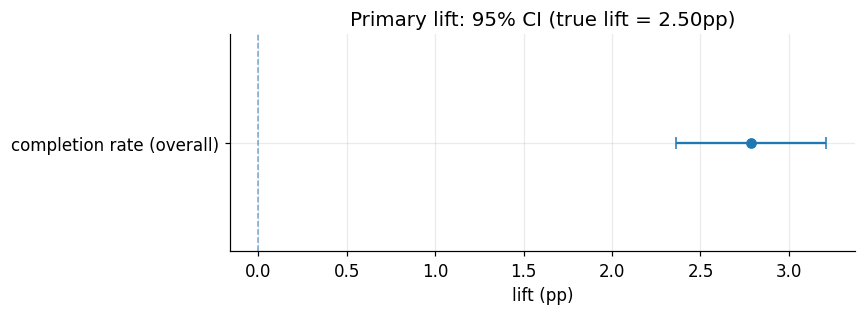

In [7]:
true_lift_pp = truth['true_lift_pp']

_ = ci_forest_plot(
    point_estimates=[primary.point_estimate * 100],
    ci_lows=[primary.ci_low * 100],
    ci_highs=[primary.ci_high * 100],
    labels=['completion rate (overall)'],
    null_value=0.0,
    xlabel='lift (pp)',
    title=f'Primary lift: 95% CI (true lift = {true_lift_pp:.2f}pp)',
    save_to=FIG_DIR / '04_primary_ci.png',
)

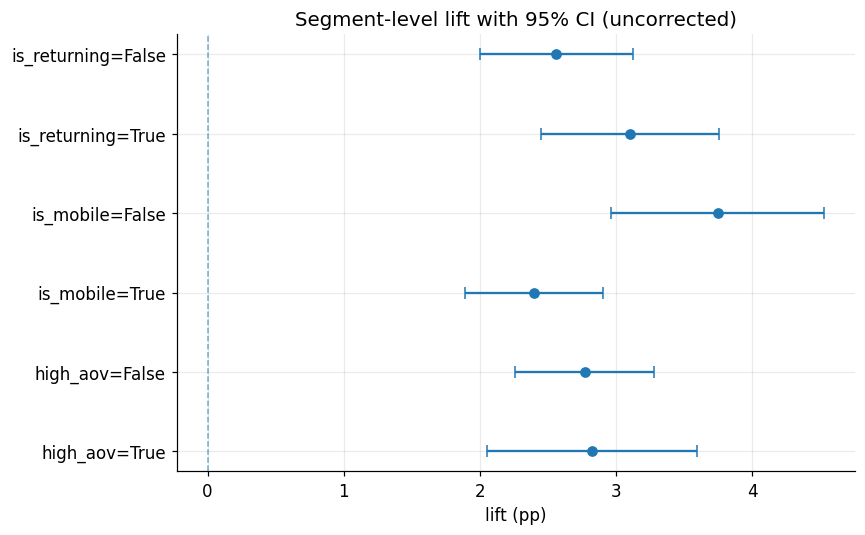

In [8]:
_ = ci_forest_plot(
    point_estimates=adjusted.lift_pp.tolist(),
    ci_lows=adjusted.ci_low_pp.tolist(),
    ci_highs=adjusted.ci_high_pp.tolist(),
    labels=[f'{c}={v}' for c, v in zip(adjusted.segment_column, adjusted.segment_value)],
    null_value=0.0,
    xlabel='lift (pp)',
    title='Segment-level lift with 95% CI (uncorrected)',
    save_to=FIG_DIR / '04_segment_forest.png',
)

## 6. Decision summary

In [9]:
decision_rows = [
    ('Primary completion lift',        f'{primary.point_estimate*100:+.3f}pp', f'p={primary.pvalue:.4g}', 'ship' if primary.significant() else 'no decision'),
    ('AOV (secondary)',                 f'{aov.point_estimate:+.2f} AED',       f'p={aov.pvalue:.3f}',     'flat as expected'),
    ('Items per order (secondary)',     f'{items.point_estimate:+.3f}',         f'p={items.pvalue:.3f}',   'flat as expected'),
    ('Guardrails flagged',              str(int(guardrails_table.flagged.sum())), '', 'pass' if not guardrails_table.flagged.any() else 'block'),
    ('Segments rejecting (Bonferroni)', str(int(adjusted.reject_bonferroni.sum())), '', 'directional only'),
    ('Segments rejecting (BH FDR)',     str(int(adjusted.reject_bh.sum())),         '', 'directional only'),
]
decision_df = pd.DataFrame(decision_rows, columns=['check', 'point estimate', 'evidence', 'verdict'])
decision_df

,check,point estimate,evidence,verdict
0,Primary completion lift,+2.786pp,p=0,ship
1,AOV (secondary),-4.22 AED,p=0.401,flat as expected
2,Items per order (secondary),+0.058,p=0.232,flat as expected
3,Guardrails flagged,1,,block
4,Segments rejecting (Bonferroni),6,,directional only
5,Segments rejecting (BH FDR),6,,directional only
